### Raffaelli Ispas Coursework Notebook

#### Necessary Imports

In [1]:
#%pip install stanza
%pip install spacy
#%pip install tokenizers==0.13.3
%pip install simpletransformers
%pip install transformers
%pip install numpy
%pip install torch
%pip install scikit-learn
%pip install matplotlib
%pip install pandas
%pip install nltk


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import random
import os
from pathlib import Path
#import stanza
import re
import spacy
from transformers import pipeline
import nltk

In [3]:
# Check for Cuda
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [4]:
# Load the data and define directories
# Local environment / I may change this later to something colab appropriate
#DATA_PATH = os.path.join(os.getcwd(), 'data')
#pcl_main_data_file = DATA_PATH + r'\dontpatronizeme_pcl.tsv'
#pcl_train_data_file = DATA_PATH + r'\train_semeval_parids-labels.csv'
#pcl_test_data_file = DATA_PATH + r'\dev_semeval_parids-labels.csv'

from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = '/content/drive/MyDrive/NLP_Data'

pcl_main_data_file = DATA_PATH + r'/dontpatronizeme_pcl.tsv'
pcl_train_data_file = DATA_PATH + r'/train_semeval_parids-labels.csv'
pcl_test_data_file = DATA_PATH + r'/dev_semeval_parids-labels.csv'

# Using column names and instructions as found on the readme
# Added delimiter to solve parsing error
pcl_df = pd.read_csv(pcl_main_data_file, names = ['par_id', 'art_id', 'keyword', 'country_code', 'text', 'label'], skiprows = 4, delimiter = '\t')

pcl_train_df = pd.read_csv(pcl_train_data_file)
pcl_test_df = pd.read_csv(pcl_test_data_file)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
pcl_df.head(5)

,par_id,art_id,keyword,country_code,text,label
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0
2,3,@@16584954,immigrant,ie,White House press secretary Sean Spicer said t...,0
3,4,@@7811231,disabled,nz,Council customers only signs would be displaye...,0
4,5,@@1494111,refugee,ca,""" Just like we received migrants fleeing El Sa...",0


In [6]:
pcl_train_df.head(5)

,par_id,label
0,4341,"[1, 0, 0, 1, 0, 0, 0]"
1,4136,"[0, 1, 0, 0, 0, 0, 0]"
2,10352,"[1, 0, 0, 0, 0, 1, 0]"
3,8279,"[0, 0, 0, 1, 0, 0, 0]"
4,1164,"[1, 0, 0, 1, 1, 1, 0]"


In [7]:
pcl_test_df.head(5)

,par_id,label
0,4046,"[1, 0, 0, 1, 0, 0, 0]"
1,1279,"[0, 1, 0, 0, 0, 0, 0]"
2,8330,"[0, 0, 1, 0, 0, 0, 0]"
3,4063,"[1, 0, 0, 1, 1, 1, 0]"
4,4089,"[1, 0, 0, 0, 0, 0, 0]"


### Stage 2: Exercise 2:

For this part I chose to go with 2 of the proposed EDAs in the Appendix.
 - Basic Statistical Profiling
 - Semantic and Syntactic Exploration

In [8]:
# Let's first handle the Basic Statistical Profiling
# That is computing the following 3 components as instructed in the Appendix for Stage 2:
#   - Token Count
#   - Vocabulary Size
#   - Class Distribution 

################################### Token Count ################################### 
min_token = float('inf')
max_token = float(0)
avg_token = []
#punctuations = "[\'s,/.\]"
#stop_word = ["the", "a", "that", "is", "and", "or", "an"] # Siimilar to Tutorial #1

unique_words = [] # Empty list storing all the unique words found while scanning,
# excluding the stop words already in the is_punct built in function from spacy

sample_tokenized_sentence = ''
sample_single_token_sentence = ''

# We were told during tutorial #1 that we should use libraries like spacy or stanza when working on
# an NLP task over nltk as they offer a higher level of abstraction. For this task I will be using spacy
#stanza.download('en')
# nlp = spacy.load('en_core_web_sm')
#nlp = stanza.Pipeline('en', processors = 'tokenize')

for i in pcl_df['text']:
    local_tokens = []
    #document = nlp(str(i).lower()) # Creating spacy-type "document" and making sure to lowercase everything 
    i = str(i) 

    for j in i.split(' '): # Simple split, no lowercasing for maximum analysis of the raw data
        local_tokens.append(j)
        unique_words.append(j) # Just appending every single token to a list so we can check uniqueness

    avg_token.append(len(local_tokens)) # Appending all the token lengths to the average to later divide by total

    # Save a couple tokenized sentences for visualization
    if (len(local_tokens) == 22):
        sample_tokenized_sentence = local_tokens
    if (len(local_tokens) == 1):
        sample_single_token_sentence = local_tokens

    # Min/Max Tokens handling
    if len(local_tokens) < min_token:
        min_token = len(local_tokens)
    elif len(local_tokens) > max_token:
        max_token = len(local_tokens)
    else:
        continue

# Compute final average
final_avg = sum(avg_token) / len(avg_token)

print(f'Average Tokens: {final_avg:.2f}')
print(f'Minimum Number of Tokens per text: {min_token}')
print(f'Maximum Number of Tokens per text: {max_token}')

print(f'Sample tokenized sentence before any pre-processing: {sample_tokenized_sentence}')
print(f'Sample tokenized sentence with singular token before pre-precessing: {sample_single_token_sentence}')

Average Tokens: 48.42
Minimum Number of Tokens per text: 1
Maximum Number of Tokens per text: 909
Sample tokenized sentence before any pre-processing: ['Lord', 'Noon', ',', 'a', 'Labour', 'peer', 'and', 'donor', ',', 'said', 'the', 'mansion', 'tax', 'was', 'a', '"', 'hopeless', 'and', 'desperate', 'idea', '"', '.']
Sample tokenized sentence with singular token before pre-precessing: ['nan']


In [9]:
################################### Vocabulary ################################### 

# We have already added every token to a list, which we can just check for uniqueness
unique_words_counter = len(list(set(unique_words)))

print(f'Total Number of Unique Words in the Vocabulary: {unique_words_counter}')

Total Number of Unique Words in the Vocabulary: 37412


In [10]:
################################### Class Distribution ################################### 

# Now let's compute the class distribution
NO_PCL_dist = (len(pcl_df[(pcl_df['label'] == 0) | (pcl_df['label'] == 1)]) / len(pcl_df)) * 100
PCL_dist = (len(pcl_df[(pcl_df['label'] == 2) | (pcl_df['label'] == 3) | (pcl_df['label'] == 4)]) / len(pcl_df)) * 100

print(f'Our PCL Distribution is: {PCL_dist:.2f}%')
print(f'Our NO PCL Distribution is: {NO_PCL_dist:.2f}%')


Our PCL Distribution is: 9.49%
Our NO PCL Distribution is: 90.51%


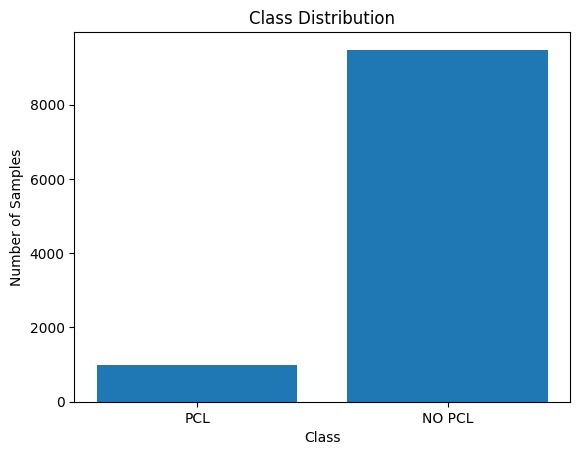

In [11]:
# Let's plot this for better visualization in the class distribution
# I will use a histogram with classes on the x-axis and number of labels on
# the y-axis
no_pcl_samples = len(pcl_df[(pcl_df['label'] == 0) | (pcl_df['label'] == 1)])
pcl_samples = len(pcl_df[(pcl_df['label'] == 2) | (pcl_df['label'] == 3) | (pcl_df['label'] == 4)])
distribs = [pcl_samples, no_pcl_samples]
classes = ['PCL', 'NO PCL']

plt.figure()
plt.bar(classes, distribs)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.show()

In [12]:
# The second EDA I will be looking at is Identifying "Noise" and Artifacts
# That is computing the following 3 components as instructed in the Appendix for Stage 2, with a change in the second component
# replacing it with checks for punctuation and stop words instead:
#   - Duplicates
#   - Punctuation, Stop Words, NaNs, and Special Characters
#   - Outliers

################################### Duplicates ################################### 

# Let us first check if there are any duplicate entries:
duplicates_exist = False # Variable initially set to false

if (pcl_df['text'].duplicated().any()):
    duplicates_exist = True
else:
    duplicates_exist = False

print(f'There are duplicate entries in our pcl dataset: {duplicates_exist}')

There are duplicate entries in our pcl dataset: False


In [13]:
################################### Punctuation, Stop Words, NaNs, and Special Characters ###################################

import string
from nltk.corpus import stopwords
# String has a built in function to check for punctuation
punct_exist = False # Variable initially set to false
punct = string.punctuation

punct_entry = 0

for i in pcl_df['text']:
    puncts = False
    i = str(i)
    for j in punct:
        if j in i:
            punct_exist = True
            puncts = True
        else:
            continue
    if puncts:
        punct_entry += 1
    else:
        continue

# Let's now check if stop words exist. We can use the nltk built in function stopwords
# We will lowercase all sentences to ensure proper detection of stopwords
nltk.download('stopwords')
#print(set(stopwords.words('english')))
stopword_list = list(set(stopwords.words('english')))

stop_words_exist = False
stopword_entry = 0

for i in pcl_df['text']:
    stopword = False
    i = str(i).lower() # Setting each sentence to lowercase as the stopwords are all lowercase, better computation

    if i == 'nan': # Apparently if I convert a NaN to string, it ends up being 'nan', then gets picked up by some stop word
        continue

    for j in stopword_list:
        if j in i:
            stop_words_exist = True
            stopword = True
        else:
            continue
    if stopword:
        stopword_entry += 1
    else:
        continue

# Now let's check how many NaNs we have in the dataset
nan_count = 0
for i in pcl_df['text']:
    i = str(i)

    if i == 'nan':
        nan_count += 1
    else:
        continue

# Checking for special characters in the entries
# To implement this, I had to use external sources, such as the regex documentation to help me remember (haven't used it in 4 years)

special_chars = ['~', '@', '#', '^', '&', '*', '+', '=', '_', '/', '|', '<', '>'] # Initially I had chars like [] as well, but then read about English grammar, and these are used to
# enclose/clarify some information in the sentence. Therefore I won't remove them anymore
special_chars_exist = False
special_char_entry = 0

for i in pcl_df['text']:
    i = str(i)
    specials = False
    for j in special_chars:
        if j in i:
            special_chars_exist = True
            specials = True
        else:
            continue
        
    if specials:
        special_char_entry += 1
    else:
        continue

# Print block
print(f'\nThere are punctuation marks in the entries of PCL dataset: {punct_exist}')
print(f'Number of entries that contain punctuation: {punct_entry}')
print(f'Total number of entries in the pcl dataset: {len(pcl_df['text'])}')
print('\n')
print(f'There are stop words in the entries of PCL dataset: {stop_words_exist}')
print(f'Number of entries that contain stop words: {stopword_entry}')
print(f'Total number of entries in the pcl dataset: {len(pcl_df['text'])}')
print('\n')
print(f'We have the following number of NaN entries in the pcl dataset: {nan_count}')
print('\n')
print(f'There are special characters in the entries of PCL dataset: {special_chars_exist}')
print(f'Number of entries that contain at least a special character: {special_char_entry}')
print(f'Total number of entries in the pcl dataset: {len(pcl_df['text'])}')
print('\n')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



There are punctuation marks in the entries of PCL dataset: True
Number of entries that contain punctuation: 10325
Total number of entries in the pcl dataset: 10469


There are stop words in the entries of PCL dataset: True
Number of entries that contain stop words: 10468
Total number of entries in the pcl dataset: 10469


We have the following number of NaN entries in the pcl dataset: 1


There are special characters in the entries of PCL dataset: True
Number of entries that contain at least a special character: 763
Total number of entries in the pcl dataset: 10469




In [14]:
################################### Outliers ###################################

# For this part we can reuse the code created earlier for the raw split of tokens
# According to that collected data, the average 48.42 tokens per entry, with a minimum of 1 (that's a NaN),
# and a maximum of 909. Clearly an immense difference.

# That being said, the approach I will do here is using a method I learned in the past called Inter Quartile Range (IQR)
# I will also attach a reference to how the algorithm works in the reference section

num_tokens = avg_token.copy()
tokens_num_df = pd.DataFrame(num_tokens)

iqr = tokens_num_df[0].quantile(0.75) - tokens_num_df[0].quantile(0.25)

low_bound = tokens_num_df[0].quantile(0.25) - (1.5 * iqr)
high_bound = tokens_num_df[0].quantile(0.75) + (1.5 * iqr)

outlier_count = 0

for i in avg_token:
    if (i < low_bound) or (i > high_bound):
        outlier_count += 1
    else:
        continue

print(f'Total number of entries in the pcl dataset: {len(pcl_df['text'])}')
print(f'Total number of outliers in the pcl dataset: {outlier_count}')
print(f'Percentage of outliers in the pcl dataset: {((outlier_count / len(pcl_df['text'])) * 100):.2f}%')

Total number of entries in the pcl dataset: 10469
Total number of outliers in the pcl dataset: 455
Percentage of outliers in the pcl dataset: 4.35%


In [15]:
pcl_train_df['label'].head(5)

,label
0,"[1, 0, 0, 1, 0, 0, 0]"
1,"[0, 1, 0, 0, 0, 0, 0]"
2,"[1, 0, 0, 0, 0, 1, 0]"
3,"[0, 0, 0, 1, 0, 0, 0]"
4,"[1, 0, 0, 1, 1, 1, 0]"


In [16]:
# First build the train and test datasets from the provided splits
import ast
# Let's drop the category labels and import the provided ones in the original file as follows:
pcl_train_df_copy = pcl_train_df.copy()
pcl_test_df_copy = pcl_test_df.copy()

pcl_train_df_copy = pcl_train_df_copy.drop(columns = ['label'])
pcl_test_df_copy = pcl_test_df_copy.drop(columns = ['label'])

x_train = pcl_train_df_copy.merge(pcl_df, on = 'par_id', how = 'inner')
x_test = pcl_test_df_copy.merge(pcl_df, on = 'par_id', how = 'inner')

#for i in x_train['label']:   

# Update the labels from 0-4 to 0 if (0, or 1) and 1 if (2, 3, or 4)
x_train['label'] = x_train['label'].apply(lambda x: 0 if x <= 1 else 1) # If the label is > 1, then it will set it to 1, and 0 otherwise
x_test['label'] = x_test['label'].apply(lambda z: 0 if z <= 1 else 1) # Same for test

# In order to use DeBERTa V3, we need to ensure that the label column is actually called "labels" as that is what it expects
x_train = x_train.rename(columns = {'label': 'labels'})
x_test = x_test.rename(columns = {'label': 'labels'})

# Create separate label df to hold the labels for train and test respectively
#y_train = x_train['label'].copy()
#y_test = x_test['label'].copy()
#x_train = x_train.drop(columns = ['label'])
#x_test = x_test.drop(columns = ['label'])

# Check shapes
print(f'Train DF shape is: {pcl_train_df_copy.shape}')
print(f'Test DF shape is: {pcl_test_df_copy.shape}')
print(f'Merged x_train shape is: {x_train.shape}')
print(f'Merged x_test shape is: {x_test.shape}')
#print(f'Shape of Ground Truth for Training is: {y_train.shape}')
#print(f'Shape of Ground Truth for Testing is: {y_test.shape}')

Train DF shape is: (8375, 1)
Test DF shape is: (2094, 1)
Merged x_train shape is: (8375, 6)
Merged x_test shape is: (2094, 6)


In [17]:
x_train.head(5)

,par_id,art_id,keyword,country_code,text,labels
0,4341,@@17139403,poor-families,gb,"The scheme saw an estimated 150,000 children f...",1
1,4136,@@22273328,homeless,za,Durban 's homeless communities reconciliation ...,1
2,10352,@@21102155,poor-families,lk,The next immediate problem that cropped up was...,1
3,8279,@@21220476,vulnerable,nz,Far more important than the implications for t...,1
4,1164,@@14727121,poor-families,gh,To strengthen child-sensitive social protectio...,1


### Pre-processing
- Primarily removing special characters to help the model gain better performance

In [18]:
# Let's remove the special characters as they do not offer any relevant insight for the model

filtered_entry = []
for i in pcl_df['text']:
    i = str(i)

    for j in special_chars:
        i = i.replace(j, '')

    filtered_entry.append(i)

pcl_df['text'] = filtered_entry

# Also fill out the NaNs
x_train['text'] = x_train['text'].astype(str).fillna("") # Filling out the NaNs with empty strings
# because I was getting some errors
x_test['text'] = x_test['text'].astype(str).fillna("")


In [19]:
# Let's check again our dataset stats
# I will be reusing my code from above

special_chars_exist = False
special_char_entry = 0

for i in pcl_df['text']:
    i = str(i)
    specials = False
    for j in special_chars:
        if j in i:
            special_chars_exist = True
            specials = True
        else:
            continue
        
    if specials:
        special_char_entry += 1
    else:
        continue

print(f'There are special characters in the entries of PCL dataset: {special_chars_exist}')
print(f'Number of entries that contain at least a special character: {special_char_entry}')
print(f'Total number of entries in the pcl dataset: {len(pcl_df['text'])}')

There are special characters in the entries of PCL dataset: False
Number of entries that contain at least a special character: 0
Total number of entries in the pcl dataset: 10469


### Fine-Tuning
- Please note that, as I have also specified several times throughout the code cells, I am consistently using the code provided in the Tutorial 6 exercises as a reference for this implementation

In [69]:
# Let's first run the default DeBERTaV3 without any finetuning and copying the exact same model arguments
# as the RoBERTa baseline provided in the challenge for task 1.
#from simpletransformers.classification import ClassificationModel
from transformers import AutoModelForSequenceClassification, AutoTokenizer, TrainingArguments, Trainer
from torch.utils.data import DataLoader
from datasets import Dataset
#from transformers import DebertaForSequenceClassification, DebertaTokenizer
from transformers import RobertaForSequenceClassification, RobertaTokenizer
import tqdm
from sklearn.metrics import classification_report, f1_score

# Following tutorial 6 implementation as a helper here

class OlidDataset(torch.utils.data.Dataset):
    def __init__(self, tokenizer, input_set):
        self.tokenizer = tokenizer
        self.texts = input_set['text'].reset_index(drop = True).tolist() # Had to add this due to out of range key error
        self.labels = input_set['labels'].reset_index(drop = True).tolist()

    def collate_fn(self, batch):
        texts = []
        labels = []

        for b in batch:
            texts.append(str(b['text']))
            labels.append(b['labels'])

        encodings = self.tokenizer(texts, padding = True, truncation = True, max_length = 128)
        # pt didn't work, and I was getting only lists for some reasons, so I am converting everything to
        # tensor

        results = {
            'input_ids': torch.tensor(encodings['input_ids']),
            'labels': torch.tensor(labels),
            'attention_mask': torch.tensor(encodings['attention_mask'])
        }

        return results

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        item = {'text': self.texts[idx], 'labels': self.labels[idx]}
        return item        
    

# Modifying the loss to a weighted one to combat the sample imbalance between the 2 classes (as shown in Stage 2 Analysis)
# For this implementation I will be using Tutorial 6 as a reference to help me

class Trainer_WL(Trainer):
    def compute_loss(self, model, inputs, **kwargs):
        labels = inputs['labels']
        outputs = model(**inputs)

        # Here we employ a weighted loss to balance the penalty of misclassification in our imbalanced dataset
        penalty = [round(PCL_dist / 100, 2), round(NO_PCL_dist / 100, 2)]
        new_weights = torch.tensor(penalty).to(device)

        wl_loss = nn.CrossEntropyLoss(weight= new_weights)
        loss_weighted = wl_loss(outputs.logits.view(-1, 2), labels.view(-1))

        loss = loss_weighted

        return loss
    

# Now we use and adapt the helper functions for evaluation provided by Instructor in Tutorial 6
def predict_PCL(input, tokenizer, model):
    model.eval()
    encodings = tokenizer(input, return_tensors= 'pt', padding = True, truncation = True, max_length = 128).to(device)

    output = model(**encodings)

    preds = torch.max(output.logits, dim = -1)
    return {'prediction': preds[1], 'confidence': [preds[0]]}

def evaluate(model, tokenizer, data_loader):
    total_counter = 0
    correct_counter = 0

    preds = []
    total_labels = []

    with torch.no_grad():
        for data in tqdm.tqdm(data_loader):
            labels = {}
            labels['labels'] = data['labels']
            pcl = data['text']

            pred = predict_PCL(pcl, tokenizer, model)

            preds.append(pred['prediction'].tolist())
            total_labels.append(labels['labels'].tolist())

    f1 = f1_score(total_labels, preds)
    report = classification_report(total_labels, preds, target_names= ['NOT PCL', 'PCL'], output_dict = True)

    return (report, f1)

In [21]:
tuning_grid = {'learning_rate': [1e-7, 1e-5],
               'num_train_epochs': [3, 7]}

tuning_results = {} # empty dictionary to store our results

for learning_rate in tuning_grid['learning_rate']:
    for num_train_epochs in tuning_grid['num_train_epochs']:


        #base_model_debertav3 = ClassificationModel('deberta', 'microsoft/deberta-v3-base', args = base_model_args,
        #                                           num_labels = 2)
        # Unlike Tutorial 6 where we had to create a custome model, for our base one we can just use the DebertaForSequenceClassification

        base_model_roberta = RobertaForSequenceClassification.from_pretrained('roberta-base')
        tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

        #x_train_tokenized = tokenizer(x_train['text'].tolist(), padding = True, truncation = True)
        #x_test_tokenized = tokenizer(x_test['test'].tolist(), padding = True, truncation = True)

        x_train_tokenized = OlidDataset(tokenizer, x_train)
        x_test_tokenized = OlidDataset(tokenizer, x_test)

        batch = [sample for sample in x_train_tokenized]

        # Now we train our base model, just like we did during Tutorial 6
        training_args = TrainingArguments(
            output_dir= DATA_PATH + r'/outputs',
            learning_rate= learning_rate,
            logging_steps= 100,
            per_device_train_batch_size= 32,
            num_train_epochs= num_train_epochs,
            remove_unused_columns= False # As recommended in Tutorial 6 to avoid drops of data from our batch 
            # when the collator_fn runs 
        )

        trainer = Trainer_WL(
            model = base_model_roberta,
            args = training_args,
            train_dataset= x_train_tokenized,
            data_collator= x_train_tokenized.collate_fn
        )# Default trainer

        # Moving the model to cuda so it trains faster
        base_model_roberta.to(device)

        trainer.train()

        trainer.save_model(DATA_PATH + r'/models/base_roberta_model')

        # Now we use them to evaluate this model
        # Load up the model we just trained
        model = RobertaForSequenceClassification.from_pretrained(DATA_PATH + r'/models/base_roberta_model/')
        model.to(device)
        # Load up the test data
        test_load = DataLoader(x_test_tokenized)

        metric_report, f1 = evaluate(model, tokenizer, test_load)

        tuning_results['learning_rate'] = learning_rate
        tuning_results['num_train_epochs'] = num_train_epochs
        tuning_results['f1_score'] = f1
        tuning_results['metric_report'] = metric_report

        #print(metric_report)
        #print(metric_report['NOT PCL'])
        print(f'\nCurrent Stats of Tuning:')
        print(f'Learning Rate = {learning_rate}, Epochs Num = {num_train_epochs}')
        print(f'F1 Score: {f1}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
100,0.708524
200,0.706930
300,0.706660
400,0.703487
500,0.709623
600,0.707930
700,0.703980


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

100%|██████████| 2094/2094 [00:20<00:00, 102.68it/s]


Current Stats of Tuning:
Learning Rate = 1e-05, Epochs Num = 7
F1 Score: 0.5975903614457831


In [25]:
# Based on our results, seems like a lr = 1e-5 and a lr = 7 perform best. Hence, let's increase the number of epochs
# slightly and make it lr = 10 and get our final model predictions.

base_model_roberta = RobertaForSequenceClassification.from_pretrained('roberta-base')
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

#x_train_tokenized = tokenizer(x_train['text'].tolist(), padding = True, truncation = True)
#x_test_tokenized = tokenizer(x_test['test'].tolist(), padding = True, truncation = True)

x_train_tokenized = OlidDataset(tokenizer, x_train)
x_test_tokenized = OlidDataset(tokenizer, x_test)

batch = [sample for sample in x_train_tokenized]

# Now we train our base model, just like we did during Tutorial 6
training_args = TrainingArguments(
    output_dir= DATA_PATH + r'/outputs',
    learning_rate= 1e-5,
    logging_steps= 100,
    per_device_train_batch_size= 32,
    num_train_epochs= 9,
    remove_unused_columns= False # As recommended in Tutorial 6 to avoid drops of data from our batch 
    # when the collator_fn runs 
)

trainer = Trainer_WL(
    model = base_model_roberta,
    args = training_args,
    train_dataset= x_train_tokenized,
    data_collator= x_train_tokenized.collate_fn
)# Default trainer

# Moving the model to cuda so it trains faster
base_model_roberta.to(device)

trainer.train()

trainer.save_model(DATA_PATH + r'/models/base_roberta_model')

# Now we use them to evaluate this model
# Load up the model we just trained
model = RobertaForSequenceClassification.from_pretrained(DATA_PATH + r'/models/base_roberta_model/')
model.to(device)
# Load up the test data
test_load = DataLoader(x_test_tokenized)

metric_report, f1 = evaluate(model, tokenizer, test_load)

print(f'F1 Score: {f1}')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
100,0.652844
200,0.485035
300,0.430802
400,0.378871
500,0.390194
600,0.286082
700,0.242920
800,0.316460
900,0.220024
1000,0.231648


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

100%|██████████| 2094/2094 [00:21<00:00, 95.55it/s] 

F1 Score: 0.5646437994722955


In [52]:
# Helper function for predictions - referenced from evaluate()
def get_preds(model, tokenizer, data_loader):
    preds = []
    total_labels = []

    with torch.no_grad():
        for data in tqdm.tqdm(data_loader):
            labels = {}
            labels['labels'] = data['labels']
            pcl = data['text']

            pred = predict_PCL(pcl, tokenizer, model)

            preds.append(pred['prediction'].tolist())
            total_labels.append(labels['labels'].tolist())

    return preds

In [53]:
# Load up the model we just trained to get predictions for our dev_test dataset
model = RobertaForSequenceClassification.from_pretrained(DATA_PATH + r'/models/base_roberta_model/')
model.to(device)
# Load up the test data
test_load = DataLoader(x_test_tokenized)

preds_dev = get_preds(model, tokenizer, test_load)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

100%|██████████| 2094/2094 [00:20<00:00, 102.07it/s]


In [54]:
print(x_test_tokenized[0].keys())

dict_keys(['text', 'labels'])


In [55]:
print(x_test.head(3))

   par_id      art_id   keyword country_code  \
0    4046  @@14767805  hopeless           us   
1    1279   @@7896098   refugee           ng   
2    8330  @@17252299   refugee           ng   

                                                text  labels  
0  We also know that they can benefit by receivin...       1  
1  Pope Francis washed and kissed the feet of Mus...       1  
2  Many refugees do n't want to be resettled anyw...       1  


In [56]:
# Handling and Saving predictions to their specific par_id
clean_preds_dev = []
for i in preds_dev:
    clean_preds_dev.append(i[0])

with open(DATA_PATH + '/dev.txt', 'w') as f:
    for i in clean_preds_dev:
        f.write(f'{i}\n')

In [57]:
# Helper function for predictions - referenced from evaluate()
def get_preds_task_test(model, tokenizer, data_loader):
    preds = []

    with torch.no_grad():
        for data in tqdm.tqdm(data_loader):
            pcl = data['text']

            pred = predict_PCL(pcl, tokenizer, model)

            preds.append(pred['prediction'].tolist())

    return preds

In [61]:
# Now let's do everything for our primary final dataset
task_test_file = DATA_PATH + r'/task4_test.tsv'

# Using column names and instructions as found on the readme
# Added delimiter to solve parsing error
task_test_df = pd.read_csv(task_test_file, names = ['par_id', 'art_id', 'keyword', 'country_code', 'text', 'label'], delimiter = '\t')

#task_test_df = task_test_df.drop(columns = ['label'])
task_test_df = task_test_df.rename(columns = {'label': 'labels'})
task_test_tokenized = OlidDataset(tokenizer, task_test_df)

# Load up the model we just trained to get predictions for our dev_test dataset
model = RobertaForSequenceClassification.from_pretrained(DATA_PATH + r'/models/base_roberta_model/')
model.to(device)
# Load up the test data
task_test_load = DataLoader(task_test_tokenized)

preds_task = get_preds_task_test(model, tokenizer, task_test_load)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

100%|██████████| 3832/3832 [00:37<00:00, 102.39it/s]


In [59]:
# Handling and Saving predictions of the task4_test
clean_preds_task = []
for i in preds_task:
    clean_preds_task.append(i[0])

with open(DATA_PATH + '/test.txt', 'w') as f:
    for i in clean_preds_task:
        f.write(f'{i}\n')

In [72]:
# Let's display the dev report

# Will turn it into a pandas Dataframe for better visualization
dev_rep = pd.DataFrame(metric_report)
dev_rep

,NOT PCL,PCL,accuracy,macro avg,weighted avg
precision,0.951933,0.594444,0.921203,0.773189,0.917960
recall,0.961478,0.537688,0.921203,0.749583,0.921203
f1-score,0.956682,0.564644,0.921203,0.760663,0.919425
support,1895.000000,199.000000,0.921203,2094.000000,2094.000000


In [23]:
# Run this to get out of colab when done so I or whoever runs this uses up compute units on idle.
#from google.colab import runtime
#runtime.unassign()